# DATASET PREPARATION PHASE

*   See below for details about the reddit dataset including size, class balances, etc.
*   Dropped data (posts) that are less than 10 words (after combining title + body)
*   Combined title+post under one single data column called `text`
*   Dropped (randomly) non-depressed samples using histogram-matched downsampling — non-depressed posts are sampled to match the word-count distribution of depressed posts, then trimmed to an equal 1:1 class balance.
*   Data is split 70/15/15 into `train.csv`, `val.csv`, and `test.csv` (stratified). A smaller `small_dev.csv` (2,000 samples) is also saved for fast iteration/debugging.









In [8]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/figures', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Data Visualization/Combining/Dropping short posts

In [9]:
import pandas as pd

#reload with low_memory=False to fix the DtypeWarning
df = pd.read_csv('/content/drive/MyDrive/reddit_depression_dataset.csv', low_memory=False)

#drop unnamed index column
df = df.drop(columns=['Unnamed: 0'])

# check nulls
print("=== Null counts ===")
print(df.isnull().sum())


print("Shape")
print(f"Rows: {df.shape[0]:,} Columns: {df.shape[1]}")

print("\n COlumns")
print(df.columns.tolist())

print("\n First few rows")
df.head()

=== Null counts ===
subreddit           20
title               23
body            461051
upvotes             64
created_utc        106
num_comments    113977
label              106
dtype: int64
Shape
Rows: 2,470,778 Columns: 7

 COlumns
['subreddit', 'title', 'body', 'upvotes', 'created_utc', 'num_comments', 'label']

 First few rows


,subreddit,title,body,upvotes,created_utc,num_comments,label
0,DeepThoughts,Deep thoughts underdog,"Only when we start considering ourselves, the ...",4.0,1.405309e+09,NaN,0.0
1,DeepThoughts,"I like this sub, there's only two posts yet I ...",Anyway: Human Morality is a joke so long as th...,4.0,1.410568e+09,1.0,0.0
2,DeepThoughts,Rebirth!,Hello. \nI am the new guy in charge here (Besi...,6.0,1.416458e+09,1.0,0.0
3,DeepThoughts,"""I want to be like water. I want to slip throu...",NaN,25.0,1.416512e+09,2.0,0.0
4,DeepThoughts,Who am I?,You could take any one cell in my body and kil...,5.0,1.416516e+09,4.0,0.0


In [10]:
#combine title and body into one text field
df['text'] = df['title'].fillna('') + ' ' + df['body'].fillna('')
df['text'] = df['text'].str.strip()

#filter posts below a word threshold
df['word_count'] = df['text'].str.split().str.len()

print("=== Word count distribution ===")
print(df['word_count'].describe())

# drop posts under 10 words
df_filtered = df[df['word_count'] >= 10].copy()
print(f"\nRemoved {len(df) - len(df_filtered):,} short posts")
print(f"Remaining: {len(df_filtered):,}")

=== Word count distribution ===
count    2.470778e+06
mean     8.051664e+01
std      1.677611e+02
min      0.000000e+00
25%      1.400000e+01
50%      2.900000e+01
75%      8.000000e+01
max      1.589400e+04
Name: word_count, dtype: float64

Removed 338,252 short posts
Remaining: 2,132,526


=== Class Distribution ===
label
0.0    1990261
1.0     480411

Total posts: 2,470,778
Imbalance ratio: 4.14x


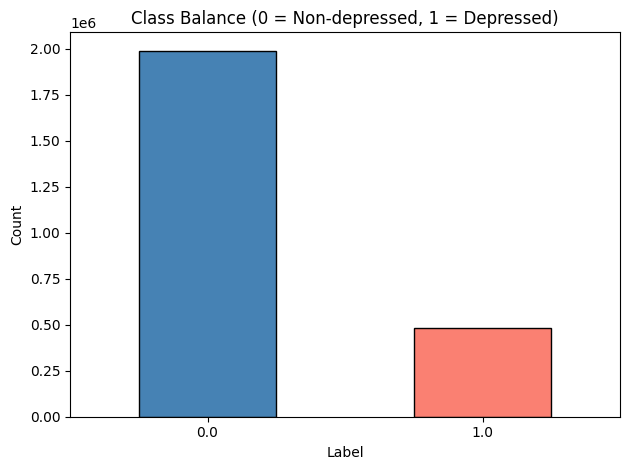

In [11]:
counts = df['label'].value_counts()

print("=== Class Distribution ===")
print(counts.to_string())
print(f"\nTotal posts: {len(df):,}")
print(f"Imbalance ratio: {counts.max() / counts.min():.2f}x")

import matplotlib.pyplot as plt
counts.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Class Balance (0 = Non-depressed, 1 = Depressed)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Check the dataset after preprocessing

In [12]:
total = len(df)
dropped = len(df) - len(df_filtered)
kept = len(df_filtered)

print(f"Original: {total:,}")
print(f"Dropped:  {dropped:,}  ({dropped/total*100:.1f}%)")
print(f"Kept:     {kept:,}  ({kept/total*100:.1f}%)")

no_body  = df['body'].isna().sum()
no_title = df['title'].isna().sum()
too_short = (df['word_count'] < 10).sum()

print("\n What was dropped?")
print(f"Null body:    {no_body:,}")
print(f"Null title:   {no_title:,}")
print(f"Under 10 words (after combining): {too_short:,}")

Original: 2,470,778
Dropped:  338,252  (13.7%)
Kept:     2,132,526  (86.3%)

 What was dropped?
Null body:    461,051
Null title:   23
Under 10 words (after combining): 338,252


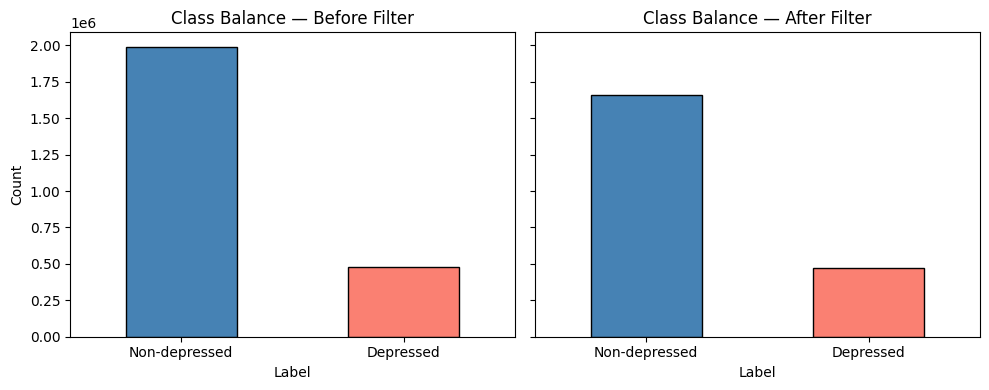

Imbalance ratio before: 4.14x
Imbalance ratio after:  3.53x


In [13]:
counts_after = df_filtered['label'].value_counts()
counts_before = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

counts_before.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Class Balance — Before Filter')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Non-depressed', 'Depressed'], rotation=0)

counts_after.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title('Class Balance — After Filter')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Non-depressed', 'Depressed'], rotation=0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/figures/class_balance_before_after_filter.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Imbalance ratio before: {counts_before.max()/counts_before.min():.2f}x")
print(f"Imbalance ratio after:  {counts_after.max()/counts_after.min():.2f}x")

In [14]:
print("=== Sample depressed posts ===")
for text in df_filtered[df_filtered['label']==1]['text'].sample(3, random_state=42):
    print(f"• {text[:200]}\n")

print("=== Sample non-depressed posts ===")
for text in df_filtered[df_filtered['label']==0]['text'].sample(3, random_state=42):
    print(f"• {text[:200]}\n")

=== Sample depressed posts ===
• ive lost my almost decade long battle, and have now desided to kill myself some time after the start of the new year i doubt anyone here will really care or read this, but hey whats one more post here

• this is my life and it’s really not a life at all. I’m in a deep state of depression and can’t get out. body dysmorphia has now consumed me. The medications made me not myself and caused nervous tics 

• I'm slipping, don't know what I'm doing. **Fair warning, there's a lot of text here.**

It's been a long time now since I've talked to anyone about how I feel. In 2013 I went to therapists a lot, I th

=== Sample non-depressed posts ===
• Hey guys , you know some subreddits for karma whoring? I need it for a meme

• It’s my birthday! Well, not really, it was actually sep 12 it’s now sep 13 and I am now writing this at 1:30 am but yesterday was my birthday, I got CASH dude like lots of cash, I also got doom eterna

• Haven't been dating my gf long, but s

In [15]:
df_filtered.head()

,subreddit,title,body,upvotes,created_utc,num_comments,label,text,word_count
0,DeepThoughts,Deep thoughts underdog,"Only when we start considering ourselves, the ...",4.0,1.405309e+09,NaN,0.0,Deep thoughts underdog Only when we start cons...,27
1,DeepThoughts,"I like this sub, there's only two posts yet I ...",Anyway: Human Morality is a joke so long as th...,4.0,1.410568e+09,1.0,0.0,"I like this sub, there's only two posts yet I ...",32
2,DeepThoughts,Rebirth!,Hello. \nI am the new guy in charge here (Besi...,6.0,1.416458e+09,1.0,0.0,Rebirth! Hello. \nI am the new guy in charge h...,38
3,DeepThoughts,"""I want to be like water. I want to slip throu...",NaN,25.0,1.416512e+09,2.0,0.0,"""I want to be like water. I want to slip throu...",20
4,DeepThoughts,Who am I?,You could take any one cell in my body and kil...,5.0,1.416516e+09,4.0,0.0,Who am I? You could take any one cell in my bo...,405


##Balancing data (same amount bw classes and of similar post length)

In [16]:
#Separate classes
depressed     = df_filtered[df_filtered['label'] == 1.0]
non_depressed = df_filtered[df_filtered['label'] == 0.0]

print(f"Depressed:     {len(depressed):,}")
print(f"Non-depressed: {len(non_depressed):,}")

# Get word count stats from depressed posts to use as matching target
dep_mean = depressed['word_count'].mean()
dep_std  = depressed['word_count'].std()
print(f"\nDepressed posts — mean words: {dep_mean:.0f}, std: {dep_std:.0f}")

Depressed:     471,180
Non-depressed: 1,661,307

Depressed posts — mean words: 202, std: 258


In [17]:
#Filter non-depressed to only posts within 1 std of depressed mean (length matching)
lower = dep_mean - dep_std
upper = dep_mean + dep_std

non_dep_matched = non_depressed[
    (non_depressed['word_count'] >= lower) &
    (non_depressed['word_count'] <= upper)
]
print(f"Non-depressed posts in length range [{lower:.0f}, {upper:.0f}]: {len(non_dep_matched):,}")

Non-depressed posts in length range [-56, 460]: 1,642,143


In [18]:
#Downsample non-depressed to match depressed count (1:1 balance)
non_dep_sampled = non_dep_matched.sample(n=len(depressed), random_state=42)

df_balanced = pd.concat([depressed, non_dep_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced dataset size: {len(df_balanced):,}")
print(df_balanced['label'].value_counts())


Balanced dataset size: 942,360
label
0.0    471180
1.0    471180
Name: count, dtype: int64


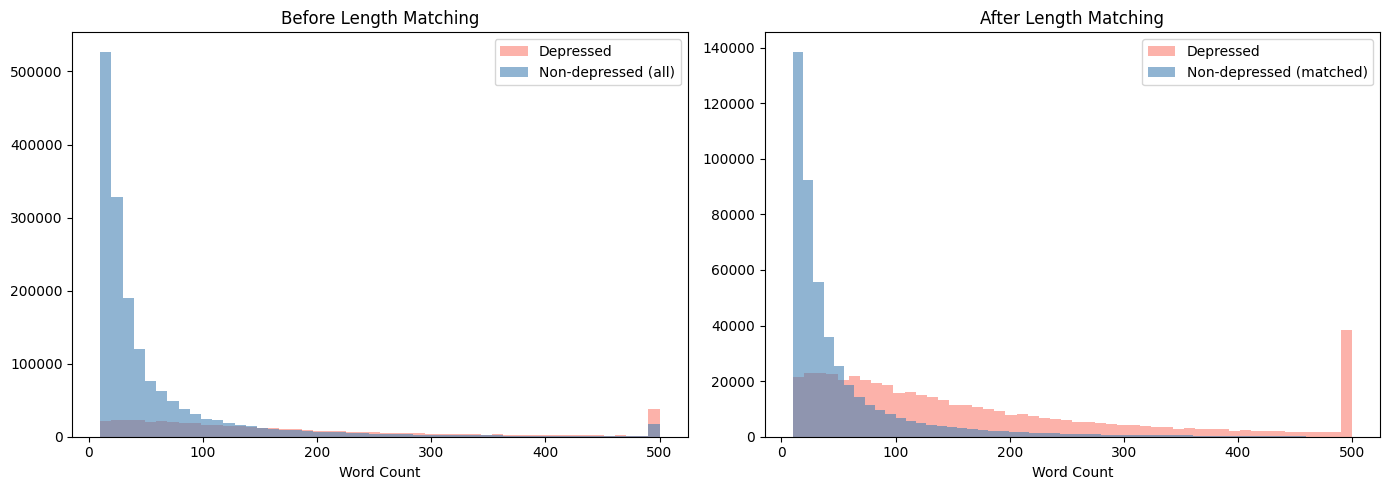

In [19]:
#Visualize  word count distributions to confirm match looks good
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# before matching
axes[0].hist(depressed['word_count'].clip(upper=500), bins=50, alpha=0.6, label='Depressed', color='salmon')
axes[0].hist(non_depressed['word_count'].clip(upper=500), bins=50, alpha=0.6, label='Non-depressed (all)', color='steelblue')
axes[0].set_title('Before Length Matching')
axes[0].set_xlabel('Word Count')
axes[0].legend()

# after matching
axes[1].hist(depressed['word_count'].clip(upper=500), bins=50, alpha=0.6, label='Depressed', color='salmon')
axes[1].hist(non_dep_sampled['word_count'].clip(upper=500), bins=50, alpha=0.6, label='Non-depressed (matched)', color='steelblue')
axes[1].set_title('After Length Matching')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/figures/word_count_before_after_matching_v1.png', dpi=300, bbox_inches='tight')
plt.show()

### This isnt that great let's try to do better below

In [20]:
# Revised approach: sample non-depressed with weights proportional to the depressed word count distribution (histogram matching)
import numpy as np

#bin the depressed posts by word count
bins = np.arange(0, df_filtered['word_count'].max() + 50, 50)  # bins of 50 words
depressed['bin'] = pd.cut(depressed['word_count'], bins=bins)
non_depressed['bin'] = pd.cut(non_depressed['word_count'], bins=bins)

#get proportion of depressed posts in each bin
dep_bin_props = depressed['bin'].value_counts(normalize=True).sort_index()

#sample non-depressed from each bin proportionally
target_n = len(depressed)
sampled_parts = []

for bin_label, prop in dep_bin_props.items():
    n_needed = int(round(prop * target_n))
    pool = non_depressed[non_depressed['bin'] == bin_label]
    n_sample = min(n_needed, len(pool))
    if n_sample > 0:
        sampled_parts.append(pool.sample(n=n_sample, random_state=42))

non_dep_matched_v2 = pd.concat(sampled_parts)

#trim/pad to exactly target_n if rounding caused drift
if len(non_dep_matched_v2) > target_n:
    non_dep_matched_v2 = non_dep_matched_v2.sample(n=target_n, random_state=42)

print(f"Depressed:         {len(depressed):,}")
print(f"Non-dep (matched): {len(non_dep_matched_v2):,}")

/tmp/ipykernel_2151/261366822.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  depressed['bin'] = pd.cut(depressed['word_count'], bins=bins)
/tmp/ipykernel_2151/261366822.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_depressed['bin'] = pd.cut(non_depressed['word_count'], bins=bins)


Depressed:         471,180
Non-dep (matched): 405,660


In [21]:
#build balanced df
df_balanced = pd.concat([
    depressed.drop(columns=['bin']),
    non_dep_matched_v2.drop(columns=['bin'])
]).sample(frac=1, random_state=42).reset_index(drop=True)

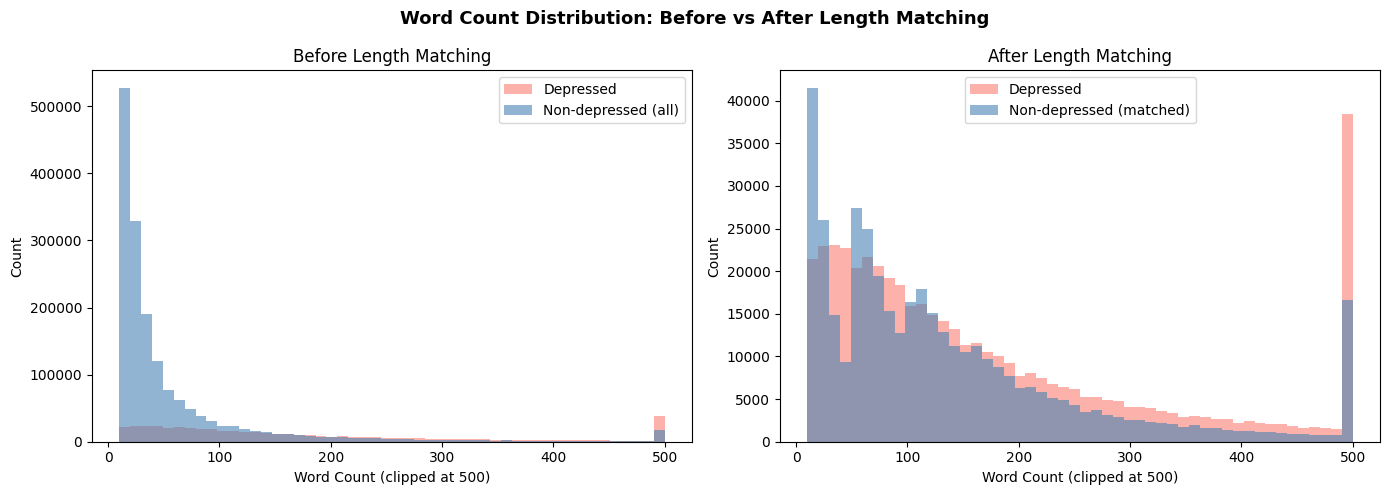

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(depressed['word_count'].clip(upper=500), bins=50, alpha=0.6, label='Depressed', color='salmon')
axes[0].hist(non_depressed['word_count'].clip(upper=500), bins=50, alpha=0.6, label='Non-depressed (all)', color='steelblue')
axes[0].set_title('Before Length Matching')
axes[0].set_xlabel('Word Count (clipped at 500)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(depressed['word_count'].clip(upper=500), bins=50, alpha=0.6, label='Depressed', color='salmon')
axes[1].hist(non_dep_matched_v2['word_count'].clip(upper=500), bins=50, alpha=0.6, label='Non-depressed (matched)', color='steelblue')
axes[1].set_title('After Length Matching')
axes[1].set_xlabel('Word Count (clipped at 500)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Word Count Distribution: Before vs After Length Matching', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/figures/word_count_before_after_matching_v2.png', dpi=300, bbox_inches='tight')
plt.show()

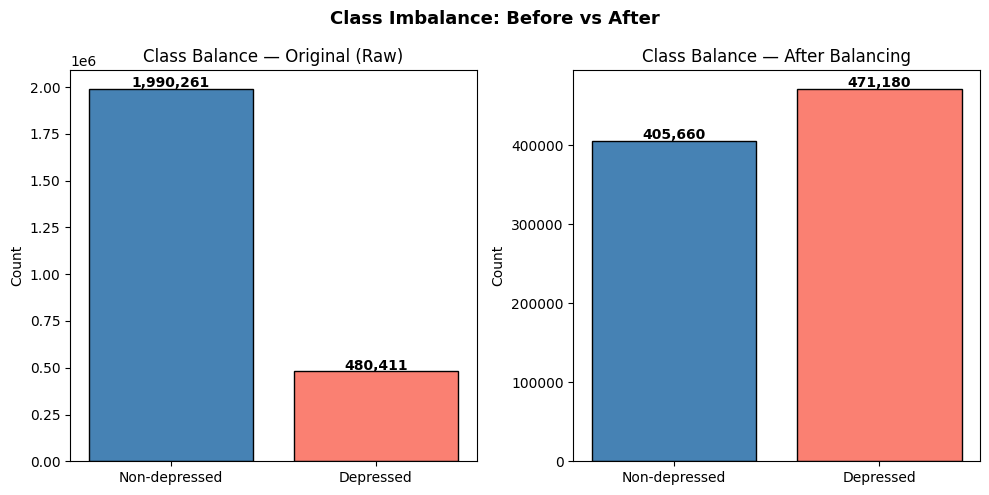

Original imbalance ratio: 4.14x
Final imbalance ratio:    1.16x


In [23]:
counts_original = df['label'].value_counts().sort_index()
counts_balanced = df_balanced['label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=False)

axes[0].bar(['Non-depressed', 'Depressed'], counts_original.values, color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Class Balance — Original (Raw)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts_original.values):
    axes[0].text(i, v + 10000, f'{v:,}', ha='center', fontweight='bold')

axes[1].bar(['Non-depressed', 'Depressed'], counts_balanced.values, color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title('Class Balance — After Balancing')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts_balanced.values):
    axes[1].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Class Imbalance: Before vs After', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/figures/class_balance_before_after_balancing.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Original imbalance ratio: {counts_original.max()/counts_original.min():.2f}x")
print(f"Final imbalance ratio:    {counts_balanced.max()/counts_balanced.min():.2f}x")

## Saving teh data to drive as csv files

In [24]:
from sklearn.model_selection import train_test_split

# 70/15/15 split, stratified to preserve class balance
df_train, df_temp = train_test_split(
    df_balanced,
    test_size=0.30,
    stratify=df_balanced['label'],
    random_state=42
)
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp['label'],
    random_state=42
)

#small dev set for fast iteration (2k, stratified)
df_small, _ = train_test_split(
    df_train,
    train_size=2_000,
    stratify=df_train['label'],
    random_state=42
)

print(f"Train:     {len(df_train):,}  ({len(df_train)/len(df_balanced)*100:.0f}%)")
print(f"Val:       {len(df_val):,}  ({len(df_val)/len(df_balanced)*100:.0f}%)")
print(f"Test:      {len(df_test):,}  ({len(df_test)/len(df_balanced)*100:.0f}%)")
print(f"Small dev: {len(df_small):,}")

#verifying class balance is preserved in each split
print("\n=== Class ratios per split ===")
for name, split in [('train', df_train), ('val', df_val), ('test', df_test), ('small', df_small)]:
    vc = split['label'].value_counts(normalize=True).sort_index()
    print(f"{name:6s}: {vc[0.0]:.2%} non-depressed  |  {vc[1.0]:.2%} depressed")

Train:     613,788  (70%)
Val:       131,526  (15%)
Test:      131,526  (15%)
Small dev: 2,000

=== Class ratios per split ===
train : 46.26% non-depressed  |  53.74% depressed
val   : 46.26% non-depressed  |  53.74% depressed
test  : 46.26% non-depressed  |  53.74% depressed
small : 46.25% non-depressed  |  53.75% depressed


## ***IMPORTANT SEE BELOW FOR THE COLUMNS OF INTEREST***

In [25]:
#keep only the columns other teammates will actually need and save to drive
cols = ['subreddit', 'label', 'text', 'word_count']

df_train[cols].to_csv('/content/drive/MyDrive/train.csv', index=False)
df_val[cols].to_csv('/content/drive/MyDrive/val.csv', index=False)
df_test[cols].to_csv('/content/drive/MyDrive/test.csv', index=False)
df_small[cols].to_csv('/content/drive/MyDrive/small_dev.csv', index=False)

print("Saved to Drive ✓")
print("\nFiles:")
print("  train.csv")
print("  val.csv        → evaluation during training")
print("  test.csv       → final held-out evaluation, don't touch until done")
print("  small_dev.csv  → smaller veersion fo the dataset for fast iteration / debugging")

Saved to Drive ✓

Files:
  train.csv
  val.csv        → evaluation during training
  test.csv       → final held-out evaluation, don't touch until done
  small_dev.csv  → smaller veersion fo the dataset for fast iteration / debugging


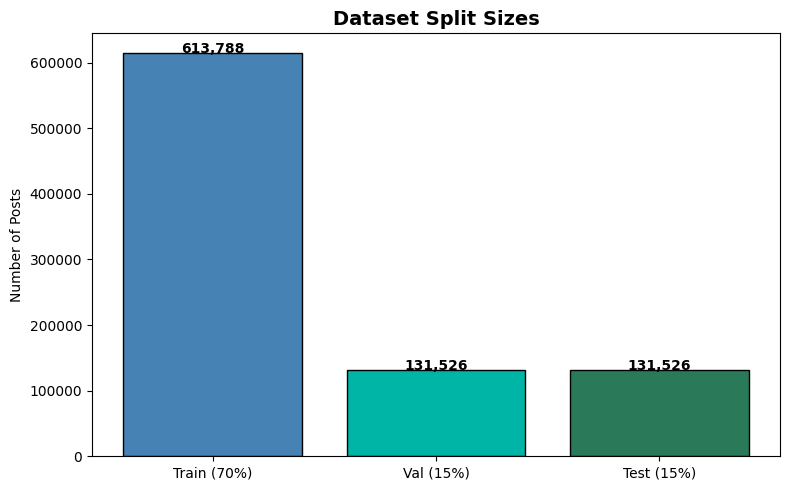

Train: 613,788  |  Val: 131,526  |  Test: 131,526


In [26]:
split_names = ['Train (70%)', 'Val (15%)', 'Test (15%)']
split_sizes = [len(df_train), len(df_val), len(df_test)]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(split_names, split_sizes, color=['steelblue', '#00B4A6', '#2A7A5A'], edgecolor='black')

ax.set_title('Dataset Split Sizes', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Posts')

for bar, size in zip(bars, split_sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{size:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/figures/dataset_split_sizes.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Train: {len(df_train):,}  |  Val: {len(df_val):,}  |  Test: {len(df_test):,}")

# Baseline Classifiers (Stephen Task)

In [27]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd

# load the splits we just saved
train = pd.read_csv('/content/drive/MyDrive/train.csv')
val   = pd.read_csv('/content/drive/MyDrive/val.csv')
test  = pd.read_csv('/content/drive/MyDrive/test.csv')

X_train, y_train = train['text'], train['label']
X_val,   y_val   = val['text'],   val['label']
X_test,  y_test  = test['text'],  test['label']

In [28]:
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy:   {acc:.4f}")
    print(f"  Macro F1:   {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=['Non-depressed', 'Depressed']))

# --- Baseline 1: Majority class ---
majority = DummyClassifier(strategy='most_frequent')
majority.fit(X_train, y_train)
evaluate("Majority Class Baseline", y_test, majority.predict(X_test))

# --- Baseline 2: Stratified random ---
stratified = DummyClassifier(strategy='stratified', random_state=42)
stratified.fit(X_train, y_train)
evaluate("Stratified Random Baseline", y_test, stratified.predict(X_test))


  Majority Class Baseline
  Accuracy:   0.5374
  Macro F1:   0.3495
               precision    recall  f1-score   support

Non-depressed       0.00      0.00      0.00     60849
    Depressed       0.54      1.00      0.70     70677

     accuracy                           0.54    131526
    macro avg       0.27      0.50      0.35    131526
 weighted avg       0.29      0.54      0.38    131526


  Stratified Random Baseline
  Accuracy:   0.5033
  Macro F1:   0.5004
               precision    recall  f1-score   support

Non-depressed       0.46      0.46      0.46     60849
    Depressed       0.54      0.54      0.54     70677

     accuracy                           0.50    131526
    macro avg       0.50      0.50      0.50    131526
 weighted avg       0.50      0.50      0.50    131526



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
# --- Baseline 3: TF-IDF + Logistic Regression ---
print("Fitting TF-IDF vectorizer...")
tfidf = TfidfVectorizer(max_features=50_000, ngram_range=(1,2), min_df=5)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train_tfidf, y_train)

evaluate("TF-IDF + Logistic Regression (val)", y_val, lr.predict(X_val_tfidf))
evaluate("TF-IDF + Logistic Regression (test)", y_test, lr.predict(X_test_tfidf))

Fitting TF-IDF vectorizer...
Training Logistic Regression...

  TF-IDF + Logistic Regression (val)
  Accuracy:   0.9188
  Macro F1:   0.9183
               precision    recall  f1-score   support

Non-depressed       0.91      0.91      0.91     60849
    Depressed       0.92      0.93      0.92     70677

     accuracy                           0.92    131526
    macro avg       0.92      0.92      0.92    131526
 weighted avg       0.92      0.92      0.92    131526


  TF-IDF + Logistic Regression (test)
  Accuracy:   0.9192
  Macro F1:   0.9187
               precision    recall  f1-score   support

Non-depressed       0.91      0.91      0.91     60849
    Depressed       0.92      0.93      0.92     70677

     accuracy                           0.92    131526
    macro avg       0.92      0.92      0.92    131526
 weighted avg       0.92      0.92      0.92    131526



## Visualization for Baseline

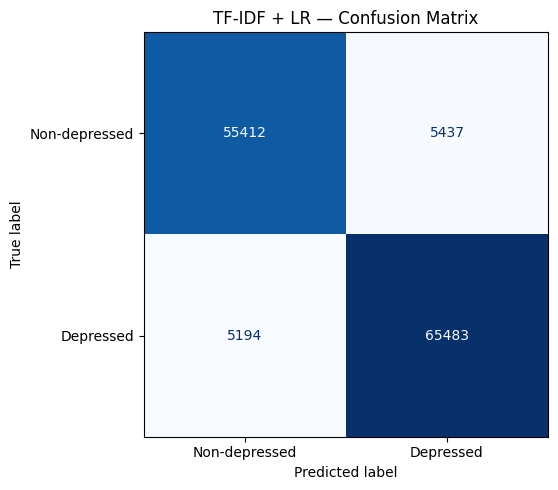

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

y_pred_test = lr.predict(X_test_tfidf)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-depressed', 'Depressed'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('TF-IDF + LR — Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

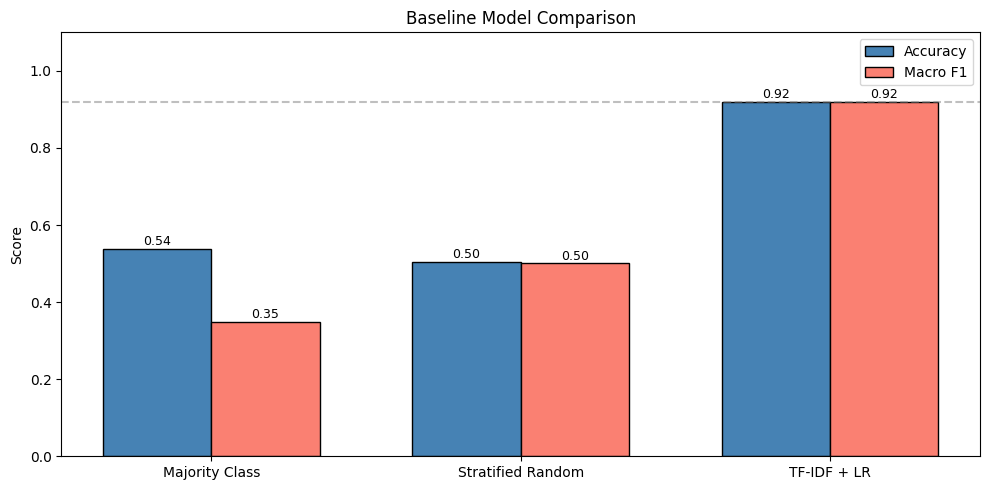

In [31]:
# Summary bar chart comparing all three baselines
models = ['Majority Class', 'Stratified Random', 'TF-IDF + LR']
accuracies = [0.5374, 0.5033, 0.9201]
f1_scores  = [0.3495, 0.5004, 0.9197]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, f1_scores,  width, label='Macro F1',  color='salmon',    edgecolor='black')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Baseline Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.axhline(y=0.92, color='gray', linestyle='--', alpha=0.5, label='TF-IDF LR score')

# add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/figures/baseline_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

# get predictions for all three models
majority_preds    = majority.predict(X_test)
stratified_preds  = stratified.predict(X_test)
lr_preds          = lr.predict(X_test_tfidf)

def get_metrics(y_true, y_pred, name):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='macro'), 4),
        'Recall':    round(recall_score(y_true, y_pred, average='macro'), 4),
        'Macro F1':  round(f1_score(y_true, y_pred, average='macro'), 4),
    }

results = pd.DataFrame([
    get_metrics(y_test, majority_preds,   'Majority Class'),
    get_metrics(y_test, stratified_preds, 'Stratified Random'),
    get_metrics(y_test, lr_preds,         'TF-IDF + LR'),
])

# highlight best value in each column
def highlight_max(s):
    is_max = s == s.max()
    return ['font-weight: bold; background-color: #d4edda' if v else '' for v in is_max]

results.set_index('Model').style\
    .format('{:.4f}')\
    .set_caption('Baseline Model Performance on Test Set')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Accuracy,Precision,Recall,Macro F1
Model,,,,
Majority Class,0.5374,0.2687,0.5000,0.3495
Stratified Random,0.5033,0.5004,0.5004,0.5004
TF-IDF + LR,0.9192,0.9188,0.9186,0.9187


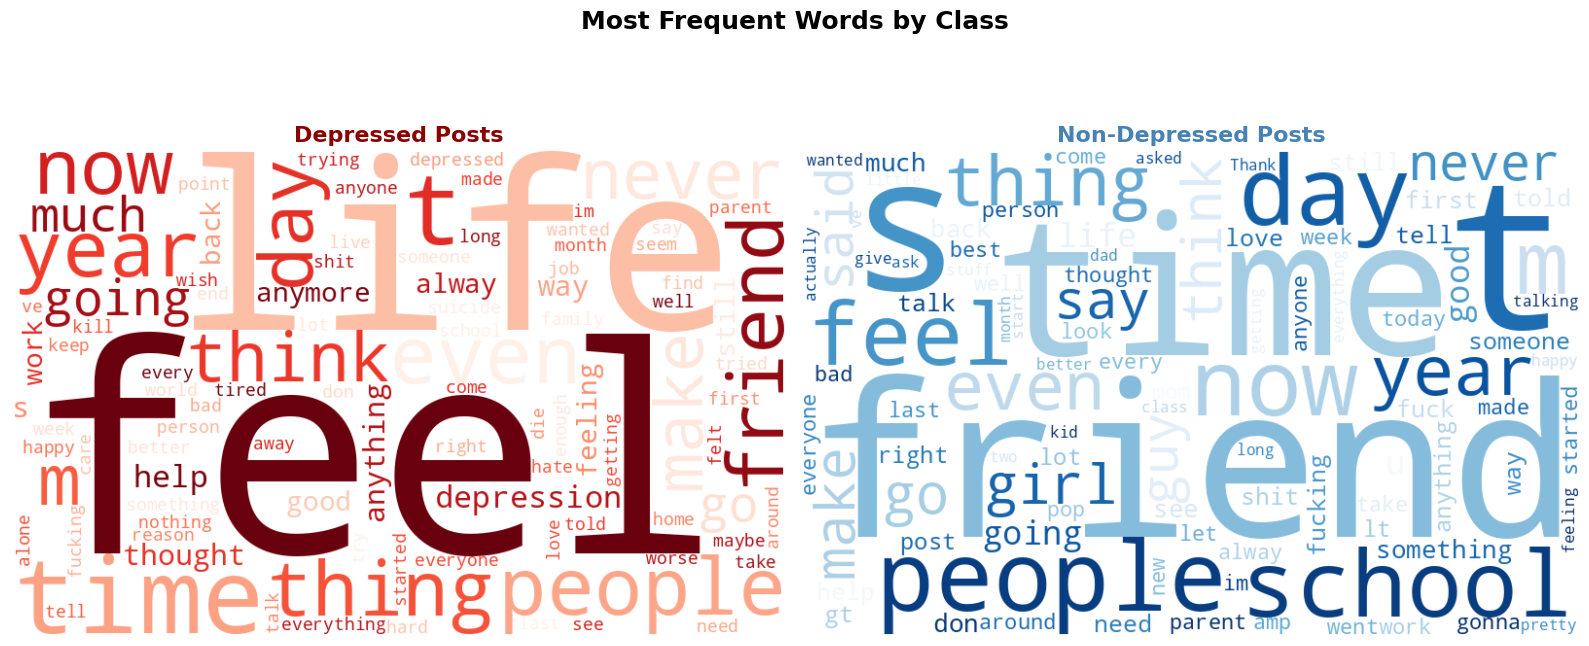

Saved to Drive


In [33]:
# install wordcloud if needed
!pip install wordcloud --quiet

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# get text for each class from training set
depressed_text     = ' '.join(df_train[df_train['label'] == 1.0]['text'].dropna())
non_depressed_text = ' '.join(df_train[df_train['label'] == 0.0]['text'].dropna())

# custom stopwords
stopwords = set(STOPWORDS)
stopwords.update(['will', 'just', 'like', 'know', 'really', 'want', 'one', 'got', 'get'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# depressed word cloud
wc_dep = WordCloud(
    width=800, height=500,
    background_color='white',
    stopwords=stopwords,
    colormap='Reds',
    max_words=100,
    collocations=False
).generate(depressed_text)

axes[0].imshow(wc_dep, interpolation='bilinear')
axes[0].set_title('Depressed Posts', fontsize=16, fontweight='bold', color='darkred')
axes[0].axis('off')

# non-depressed word cloud
wc_nodep = WordCloud(
    width=800, height=500,
    background_color='white',
    stopwords=stopwords,
    colormap='Blues',
    max_words=100,
    collocations=False
).generate(non_depressed_text)

axes[1].imshow(wc_nodep, interpolation='bilinear')
axes[1].set_title('Non-Depressed Posts', fontsize=16, fontweight='bold', color='steelblue')
axes[1].axis('off')

plt.suptitle('Most Frequent Words by Class', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/figures/wordclouds.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to Drive")